# 🚢 Titanic

---
## 🔍 Enquête — Profil des survivants du Titanic

>
> Vous êtes analyste de données pour le **Bureau of Marine Investigation**. Le 15 avril 1912, le RMS Titanic coule après avoir heurté un iceberg. On vous demande de **produire un rapport factuel** sur les inégalités de survie à partir des données disponibles.
>
> Les 7 questions suivantes constituent votre enquête — elles se construisent les unes sur les autres pour aboutir à une conclusion argumentée.
>
**Objetif : créer une visualisation pour répondre à chaque question ci-dessous.**

## ⚙️ Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("✅ Imports OK")

df = pd.read_csv('titanic.csv')

print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

✅ Imports OK
Dataset chargé : 891 lignes × 15 colonnes


### 🟢 Question 1 — État des lieux
**Combien de passagers ont survécu ? Quel pourcentage cela représente-t-il ?**  
Affichez les chiffres absolus et les proportions. C'est votre point de départ.


survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.6
1    38.4
Name: proportion, dtype: float64


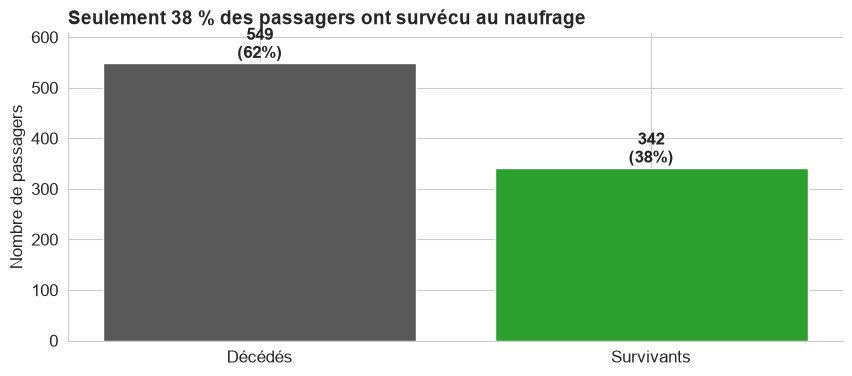

In [2]:
# Message : "Seulement 38 % des passagers ont survécu au naufrage."

# 1. Chiffres bruts et proportions
counts = df['survived'].value_counts()
props = df['survived'].value_counts(normalize=True) * 100
print(counts)
print(props.round(1))

# 2. Graphique narratif : un seul diagramme à bâtons, 2 catégories
labels = ['Décédés', 'Survivants']
values = [counts[0], counts[1]]

# Canal pré-attentif : la couleur isole les survivants (la minorité qui interpelle)
# gris foncé = décédés (neutre/sombre), vert = survivants (sain et sauf)
colors = ['#595959', '#2ca02c']

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=colors)

for bar, val, pct in zip(bars, values, [props[0], props[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{val}\n({pct:.0f}%)", ha='center', fontweight='bold')

# Titre Minto : porte directement le message, pas juste "Répartition de la survie"
ax.set_title("Seulement 38 % des passagers ont survécu au naufrage",
             fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel("Nombre de passagers")
ax.set_ylim(0, max(values) + 60)
ax.spines[['top', 'right']].set_visible(False)
plt.show()


### 🟢 Question 2 — Le facteur genre
**Calculez le taux de survie par genre.** Visualisez avec un diagramme à bâtons annoté.  
La devise *"women and children first"* semble-t-elle s'appliquer dans les données ?


sex
female    74.2
male      18.9
Name: survived, dtype: float64


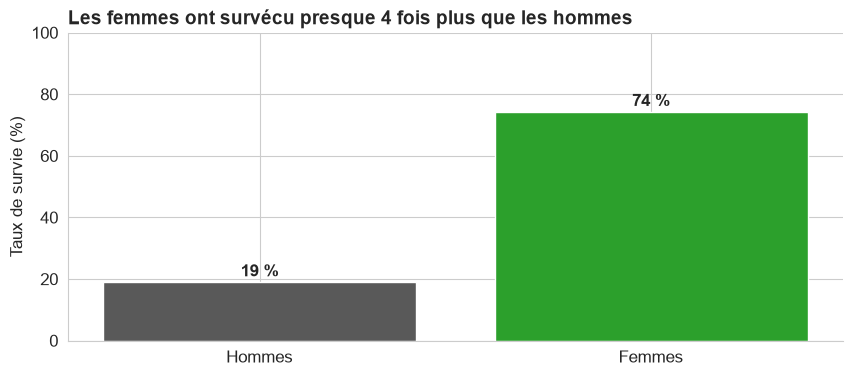

In [3]:
# Message : "Les femmes ont survécu presque 4 fois plus que les hommes : la règle a été respectée."

# 1. Taux de survie par genre
taux_survie_sexe = df.groupby('sex')['survived'].mean() * 100
print(taux_survie_sexe.round(1))

# 2. Graphique narratif : un seul diagramme à bâtons, 2 catégories
labels = ['Hommes', 'Femmes']
values = [taux_survie_sexe['male'], taux_survie_sexe['female']]

# Canal pré-attentif : la couleur isole les femmes (le groupe qui porte le message)
# gris foncé = taux faible, vert = taux élevé (même code couleur que la Q1)
colors = ['#595959', '#2ca02c']

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=colors)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.0f} %", ha='center', fontweight='bold')

# Titre Minto : porte directement le message, pas juste "Taux de survie par genre"
ax.set_title("Les femmes ont survécu presque 4 fois plus que les hommes",
             fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel("Taux de survie (%)")
ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
plt.show()


### 🟢 Question 3 — Le facteur classe sociale
**Calculez le taux de survie par classe** (`pclass`). Calculez également le tarif médian par classe.  
Quel lien observez-vous entre richesse et survie ?


pclass
1    63.0
2    47.3
3    24.2
Name: survived, dtype: float64
pclass
1    60.3
2    14.2
3     8.0
Name: fare, dtype: float64


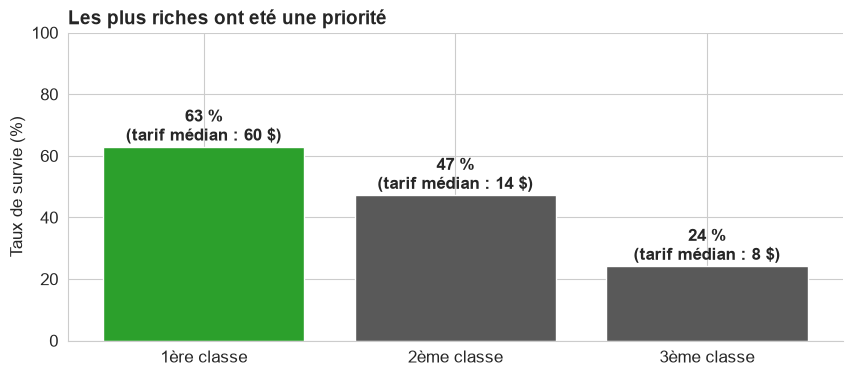

In [13]:
# Message : "Les passagers de 1ère classe ont survécu presque 3 fois plus que ceux de 3ème classe."

# 1. Taux de survie et tarif médian par classe
taux_survie_classe = df.groupby('pclass')['survived'].mean() * 100
tarif_median_classe = df.groupby('pclass')['fare'].median()
print(taux_survie_classe.round(1))
print(tarif_median_classe.round(1))

# 2. Graphique narratif : un seul diagramme à bâtons, 3 catégories
labels = ['1ère classe', '2ème classe', '3ème classe']
values = [taux_survie_classe[1], taux_survie_classe[2], taux_survie_classe[3]]
fares = [tarif_median_classe[1], tarif_median_classe[2], tarif_median_classe[3]]

# Canal pré-attentif : la couleur isole la 1ère classe (le groupe qui porte le message)
colors = ['#2ca02c', '#595959', '#595959']

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=colors)

for bar, val, fare in zip(bars, values, fares):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.0f} %\n(tarif médian : {fare:.0f} $)", ha='center', fontweight='bold')

# Titre Minto : porte directement le message, la richesse a acheté des chances de survie
ax.set_title("Les plus riches ont eté une priorité",
             fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel("Taux de survie (%)")
ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
plt.show()


### 🔴 Question 4 — Le facteur âge
Créez une colonne `tranche_age` avec `pd.cut` :
```python
bins   = [0, 12, 18, 35, 60, 100]
labels = ['Enfant (0-12)', 'Ado (13-18)', 'Adulte (19-35)', 'Senior (36-60)', 'Senior+ (60+)']
```
**Calculez le taux de survie par tranche d'âge.** Les enfants étaient-ils vraiment prioritaires ?


tranche_age
Enfant (0-12)     58.0
Ado (13-18)       42.9
Adulte (19-35)    38.3
Senior (36-60)    40.0
Senior+ (60+)     22.7
Name: survived, dtype: float64


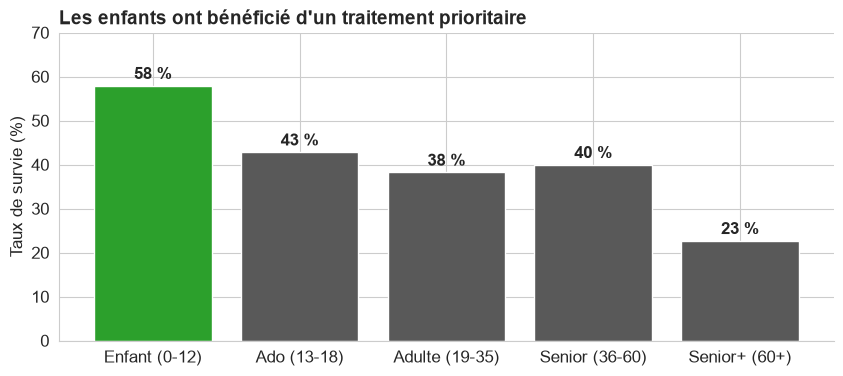

In [12]:
# Message : "Les enfants ont bénéficié d'un net traitement prioritaire face aux autres âges."

# 1. Création de la tranche d'âge + taux de survie
bins = [0, 12, 18, 35, 60, 100]
labels_age = ['Enfant (0-12)', 'Ado (13-18)', 'Adulte (19-35)', 'Senior (36-60)', 'Senior+ (60+)']
df['tranche_age'] = pd.cut(df['age'], bins=bins, labels=labels_age)

taux_survie_age = df.groupby('tranche_age')['survived'].mean() * 100
print(taux_survie_age.round(1))

# 2. Graphique narratif : un seul diagramme à bâtons, 5 catégories
values = [taux_survie_age[l] for l in labels_age]

# Canal pré-attentif : la couleur isole les enfants (le groupe qui porte le message)
colors = ['#2ca02c'] + ['#595959'] * 4

fig, ax = plt.subplots()
bars = ax.bar(labels_age, values, color=colors)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val:.0f} %", ha='center', fontweight='bold')

# Titre Minto : porte directement le message
ax.set_title("Les enfants ont bénéficié d'un traitement prioritaire",
             fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel("Taux de survie (%)")
ax.set_ylim(0, 70)
ax.spines[['top', 'right']].set_visible(False)
plt.show()


### 🔴 Question 5 — L'effet famille
Créez une colonne `famille_size` = `sibsp` + `parch` + 1 (le passager lui-même).  
Créez ensuite une colonne `statut_famille` :
- `'Seul'` si `famille_size == 1`
- `'Petite famille'` si `famille_size` entre 2 et 4
- `'Grande famille'` si `famille_size >= 5`

**Calculez le taux de survie par statut familial.** Voyager seul était-il un désavantage ?


statut_famille
Seul              30.4
Petite famille    57.9
Grande famille    16.1
Name: survived, dtype: float64


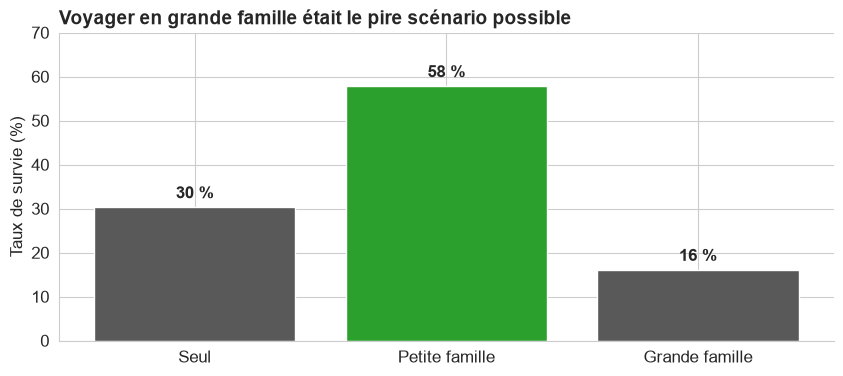

In [14]:
# Message : "Voyager en petite famille offrait les meilleures chances de survie — mieux que seul ou en grande famille."

# 1. Création des colonnes famille_size et statut_famille
df['famille_size'] = df['sibsp'] + df['parch'] + 1

def statut(n):
    if n == 1:
        return 'Seul'
    elif n <= 4:
        return 'Petite famille'
    else:
        return 'Grande famille'

df['statut_famille'] = df['famille_size'].apply(statut)

ordre = ['Seul', 'Petite famille', 'Grande famille']
taux_survie_famille = df.groupby('statut_famille')['survived'].mean().reindex(ordre) * 100
print(taux_survie_famille.round(1))

# 2. Graphique narratif : un seul diagramme à bâtons, 3 catégories
values = [taux_survie_famille[l] for l in ordre]

# Canal pré-attentif : la couleur isole la petite famille (le groupe qui porte le message)
colors = ['#595959', '#2ca02c', '#595959']

fig, ax = plt.subplots()
bars = ax.bar(ordre, values, color=colors)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.0f} %", ha='center', fontweight='bold')

# Titre Minto : porte directement le message
ax.set_title("Voyager en grande famille était le pire scénario possible",
             fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel("Taux de survie (%)")
ax.set_ylim(0, 70)
ax.spines[['top', 'right']].set_visible(False)
plt.show()


### 🔴 Question 6 — Les cas extrêmes
Comparez les deux profils opposés :
- **Profil A** : femmes de 1ère classe
- **Profil B** : hommes de 3ème classe

Pour chacun : taux de survie, âge médian, tarif médian, nombre de passagers.  
L'écart vous semble-t-il lié au sexe, à la classe, ou aux deux ?


                     Profil A (femmes 1ère classe)  \
Taux de survie (%)                            96.8   
Âge médian                                    35.0   
Tarif médian ($)                              82.7   
Nombre de passagers                           94.0   

                     Profil B (hommes 3ème classe)  
Taux de survie (%)                            13.5  
Âge médian                                    25.0  
Tarif médian ($)                               7.9  
Nombre de passagers                          347.0  


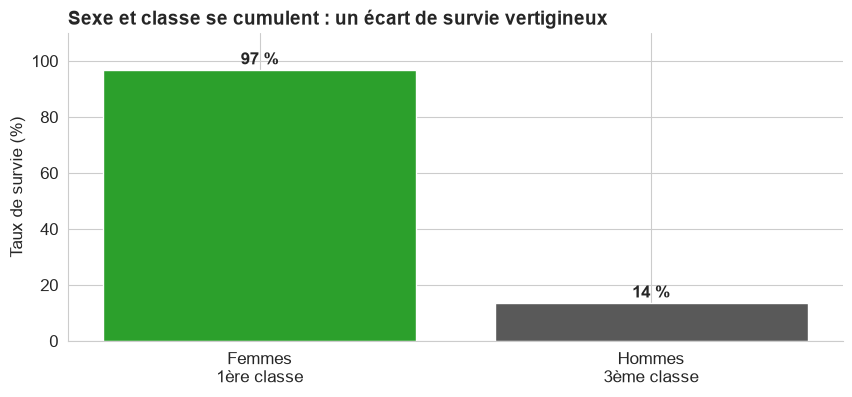

In [7]:
# Message : "L'écart de survie entre femmes de 1ère classe et hommes de 3ème classe est vertigineux : sexe et classe se cumulent."

# 1. Deux filtres booléens + stats comparatives
profil_a = df[(df['sex'] == 'female') & (df['pclass'] == 1)]
profil_b = df[(df['sex'] == 'male') & (df['pclass'] == 3)]

stats = pd.DataFrame({
    'Profil A (femmes 1ère classe)': [
        profil_a['survived'].mean() * 100,
        profil_a['age'].median(),
        profil_a['fare'].median(),
        len(profil_a),
    ],
    'Profil B (hommes 3ème classe)': [
        profil_b['survived'].mean() * 100,
        profil_b['age'].median(),
        profil_b['fare'].median(),
        len(profil_b),
    ],
}, index=['Taux de survie (%)', 'Âge médian', 'Tarif médian ($)', 'Nombre de passagers'])
print(stats.round(1))

# 2. Graphique narratif : un seul diagramme à bâtons, 2 profils opposés
labels = ['Femmes\n1ère classe', 'Hommes\n3ème classe']
values = [profil_a['survived'].mean() * 100, profil_b['survived'].mean() * 100]

# Canal pré-attentif : la couleur isole le profil favorisé
colors = ['#2ca02c', '#595959']

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=colors)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.0f} %", ha='center', fontweight='bold')

# Titre Minto : porte directement le message
ax.set_title("Sexe et classe se cumulent : un écart de survie vertigineux",
             fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel("Taux de survie (%)")
ax.set_ylim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.show()


### 💬 Question 7 — Synthèse du rapport
Rédigez ici votre **conclusion d'enquête** en quelques phrases structurées :

1. Quel est le facteur qui a eu le **plus d'impact** sur la survie ? Chiffrez votre affirmation.
2. Quel facteur vous a le plus **surpris** ou contredit votre intuition initiale ?
3. Y a-t-il une **limite** dans ces données qui vous empêche de tirer des conclusions définitives ? (Pensez aux valeurs manquantes, à la taille du dataset, à ce qui n'est pas mesuré…)


**1. Le facteur le plus impactant : le genre.**
L'écart de survie entre femmes (74 %) et hommes (19 %) est de 55 points — le plus large écart obtenu à partir d'un seul facteur, devant la classe sociale (39 points d'écart entre 1ère et 3ème classe) et le statut familial (42 points). Quand on cumule genre et classe (Q6), l'écart devient extrême : 97 % de survie pour les femmes de 1ère classe contre seulement 14 % pour les hommes de 3ème classe.

**2. Le facteur le plus surprenant : la taille de la famille.**
On aurait pu s'attendre à ce que voyager en famille protège systématiquement, mais les grandes familles (5 personnes et plus) ont le taux de survie le plus bas de toute l'enquête (16 %), en dessous même des passagers voyageant seuls (30 %). La logistique d'évacuation d'un grand groupe semble avoir joué contre eux, alors qu'une petite famille (2 à 4 personnes) obtient le meilleur taux (58 %).

**3. Limites des données.**
- La colonne `age` comporte 20 % de valeurs manquantes (177 sur 891) : l'analyse par tranche d'âge repose donc sur une base réduite et potentiellement biaisée.
- Le dataset ne couvre que 891 passagers sur environ 2 224 personnes à bord (passagers et équipage) : les conclusions ne s'appliquent qu'à cet échantillon.
- Aucune donnée sur la position de la cabine au moment du naufrage, la proximité des canots de sauvetage ou le comportement individuel — des facteurs qui ont pourtant pu jouer un rôle determinant et qui ne sont pas mesurés ici.


---
## 📋 Récapitulatif — Fonctions pandas introduites dans ce TP

| Fonction | Usage |
|----------|-------|
| `pd.read_csv('file.csv')` | Charger un fichier CSV |
| `sns.load_dataset('name')` | Charger un dataset intégré seaborn |
| `df.head(n)` / `df.tail(n)` | Premières / dernières lignes |
| `df.shape` | Dimensions (lignes, colonnes) |
| `df.columns` | Noms des colonnes |
| `df.info()` | Types + valeurs non-nulles |
| `df.dtypes` | Type de chaque colonne |
| `df['col']` | Sélectionner une colonne → Series |
| `df[['c1', 'c2']]` | Sélectionner plusieurs colonnes → DataFrame |
| `df['col'].unique()` | Valeurs distinctes |
| `df['col'].nunique()` | Nombre de valeurs distinctes |
| `df[df['col'] == val]` | Filtrage par condition |
| `(cond1) & (cond2)` / `(cond1) \| (cond2)` | ET / OU logique |
| `df.iloc[i, j]` | Accès par position |
| `df.loc[idx, 'col']` | Accès par label |
| `df.isnull().sum()` | Nombre de NaN par colonne |
| `df.isnull().mean() * 100` | Pourcentage de NaN |
| `df.dropna()` / `df.dropna(subset=['col'])` | Supprimer les lignes avec NaN |
| `df['col'].fillna(valeur)` | Remplacer les NaN |
| `df.describe()` | Statistiques descriptives (numériques) |
| `df['col'].value_counts()` | Fréquences absolues |
| `df['col'].value_counts(normalize=True)` | Fréquences relatives |
| `df['col'].median()` / `.mean()` / `.std()` | Statistiques simples |
| `df.groupby('col')['target'].mean()` | Moyenne par groupe |
| `df.groupby(['c1','c2'])['t'].mean().unstack()` | Tableau croisé |
| `df.sort_values('col', ascending=False)` | Tri décroissant |
| `pd.cut(df['col'], bins=[...], labels=[...])` | Discrétiser une variable continue |
